# Notebook 05 — Evaluation

**Goal**: Evaluate the pipeline quality through:
- Emotion–event correlation analysis (do emotions spike around goals/cards?)
- Receptivity score statistics and benchmarks
- Ad-slot distribution across match minutes
- Summary figures ready for the paper

Sections:
1. Setup
2. Load results
3. Emotion–event correlation
4. Receptivity statistics
5. Emotion around key events (goal analysis)
6. Paper-ready figures
7. Print final summary

In [6]:
import sys, os

# Robust path: works whether notebook is run from repo root, notebooks/, or Colab
_nb_dir = os.path.dirname(os.path.abspath(globals().get("__file__", os.getcwd())))
_repo_root = _nb_dir if os.path.isdir(os.path.join(_nb_dir, "src")) else os.path.dirname(_nb_dir)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation import (
    compute_emotion_event_correlation,
    compute_window_stats,
    print_summary,
    EMOTION_COLORS,
    AD_COLORS,
)

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [7]:
# ── 2. Load results ───────────────────────────────────────────────────────
scored       = pd.read_csv(f"{OUTPUT_DIR}/scored_windows.csv")
recommended  = pd.read_csv(f"{OUTPUT_DIR}/recommended_ad_slots.csv")
match_events = pd.read_csv(f"{OUTPUT_DIR}/match_events_cleaned.csv")

print(f"Scored windows     : {len(scored):,}")
print(f"Recommended slots  : {len(recommended):,}")
print(f"Match events       : {len(match_events):,}")

Scored windows     : 704
Recommended slots  : 138
Match events       : 1,475


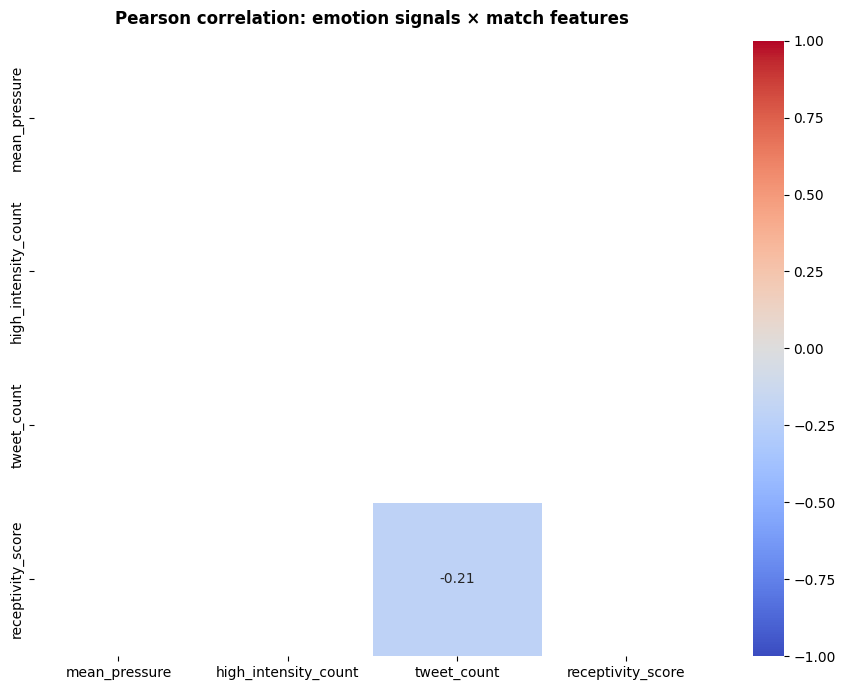

                      mean_pressure  high_intensity_count  tweet_count  receptivity_score
mean_pressure                   NaN                   NaN          NaN                NaN
high_intensity_count            NaN                   NaN          NaN                NaN
tweet_count                     NaN                   NaN        1.000             -0.212
receptivity_score               NaN                   NaN       -0.212              1.000


In [8]:
# ── 3. Correlation matrix ─────────────────────────────────────────────────
corr = compute_emotion_event_correlation(scored)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, mask=mask, linewidths=0.5)
ax.set_title("Pearson correlation: emotion signals × match features",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_matrix.png", dpi=150)
plt.show()
print(corr.to_string())

In [10]:
# ── 4. Receptivity statistics ─────────────────────────────────────────────
stats = compute_window_stats(scored)
for k, v in stats.items():
    print(f"  {k:<28} {v}")

# Distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scored["receptivity_score"], bins=40, edgecolor="white",
        color="#43aa8b", alpha=0.85)
ax.axvline(0.60, color="#43aa8b", linewidth=2, linestyle="--", label="Safe threshold (0.60)")
ax.axvline(0.40, color="#f8961e", linewidth=2, linestyle="--", label="Risky threshold (0.40)")
ax.set_title("Distribution of receptivity scores (all windows)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Receptivity score")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/receptivity_distribution.png", dpi=150)
plt.show()

KeyError: 'mean_arousal'

In [ ]:
# ── 5. Emotion around key events (goals) ──────────────────────────────────
# We look at 3 windows before and 3 windows after each goal,
# averaging arousal and joy/anger across all goals in the dataset.

goals = match_events[match_events["event_type_name"] == "Goal"].copy()
goals["goal_window"] = (goals["effective_minute"] // 5).astype(int) * 5

WINDOW_RANGE = range(-3, 4)   # -15 min to +15 min relative to goal
WINDOW_SIZE  = 5

emotion_cols = [c for c in ["joy","anger","sadness","fear","arousal","valence"]
                if c in scored.columns]

records = []
for _, goal in goals.iterrows():
    fid = goal["fixture_id"]
    gw  = goal["goal_window"]
    for offset in WINDOW_RANGE:
        target_win = gw + offset * WINDOW_SIZE
        row = scored[(scored["fixture_id"] == fid) & (scored["window_5min"] == target_win)]
        if not row.empty:
            rec = {"offset": offset}
            for col in emotion_cols:
                rec[col] = row[col].values[0]
            records.append(rec)

if records:
    goal_ctx = pd.DataFrame(records).groupby("offset")[emotion_cols].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = goal_ctx.index * WINDOW_SIZE
    for emo in [c for c in ["joy","anger","sadness","fear"] if c in goal_ctx.columns]:
        axes[0].plot(x, goal_ctx[emo], label=emo.capitalize(),
                     color=EMOTION_COLORS.get(emo), linewidth=2, marker="o")
    axes[0].axvline(0, color="black", linewidth=2, linestyle="--", label="Goal")
    axes[0].set_title("Emotion dynamics around goals", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Minutes relative to goal")
    axes[0].set_ylabel("Mean probability")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    if "arousal" in goal_ctx.columns:
        axes[1].fill_between(x, goal_ctx["arousal"], alpha=0.4, color="#e63946")
        axes[1].plot(x, goal_ctx["arousal"], color="#e63946", linewidth=2, label="Arousal", marker="o")
    if "valence" in goal_ctx.columns:
        axes[1].fill_between(x, goal_ctx["valence"].clip(0), alpha=0.3, color="#43aa8b")
        axes[1].plot(x, goal_ctx["valence"], color="#43aa8b", linewidth=2, label="Valence", marker="o")
    axes[1].axvline(0, color="black", linewidth=2, linestyle="--", label="Goal")
    axes[1].set_title("Arousal & valence around goals", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Minutes relative to goal")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/emotion_around_goals.png", dpi=150)
    plt.show()
else:
    print("No overlapping goal windows found between match events and scored tweet windows.\n"
          "This is expected when the tweet dataset (2020) and match dataset (2024/25) cover different seasons.")

In [ ]:
# ── 6. Ad slot distribution over match minutes ────────────────────────────
slot_dist = recommended.groupby("window_5min").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(slot_dist.index, slot_dist.values, width=4, color="#43aa8b", edgecolor="white")
ax.set_title("Distribution of recommended ad slots across match minutes",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Match minute")
ax.set_ylabel("Number of recommended slots")
ax.axvspan(45, 50, alpha=0.15, color="grey", label="Half-time")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ad_slot_distribution.png", dpi=150)
plt.show()

In [ ]:
# ── 7. Final summary ──────────────────────────────────────────────────────
print_summary(scored, recommended)